[+] Step 1: Synthesizing data with 50 distinct dimensions...
[+] Step 2: Extracting a 3D perspective out of the 50D space...
[+] Step 3: Compressing all 50 dimensions down to 2D via t-SNE...
[+] Step 4: Rendering the final low-dimensional cluster map...
[✓] Process complete! Artifact exported as 'high_dim_to_low_dim_tsne.png'


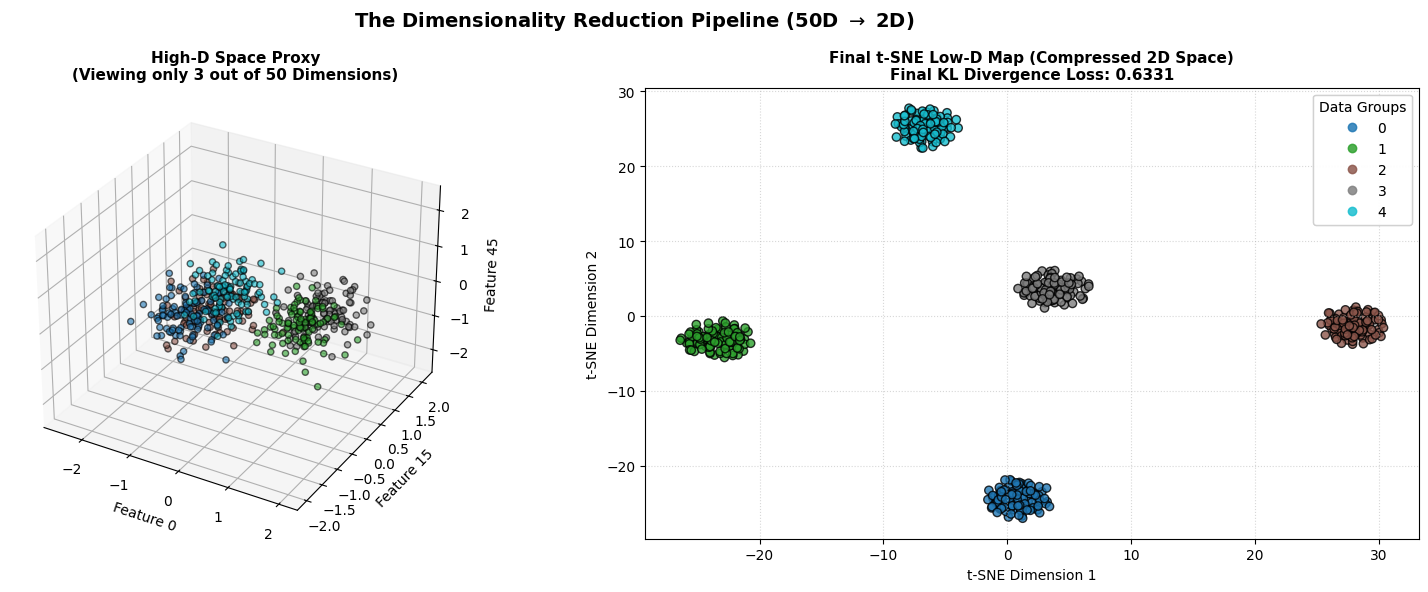

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

def run_advanced_pipeline():
    # 1. Generate massive high-dimensional data (50 features, 5 clusters)
    print("[+] Step 1: Synthesizing data with 50 distinct dimensions...")
    dimensions = 50
    clusters = 5
    X, y = make_blobs(
        n_samples=500, 
        n_features=dimensions, 
        centers=clusters, 
        cluster_std=2.5, # Slightly overlapping in 50D space
        random_state=42
    )
    
    # Standardize features to have zero mean and unit variance (best practice)
    X_scaled = StandardScaler().fit_transform(X)

    # 2. Visualize the high-dimensional space (Using 3 random dimensions as a proxy)
    print("[+] Step 2: Extracting a 3D perspective out of the 50D space...")
    fig = plt.figure(figsize=(16, 6))
    
    ax_high = fig.add_subplot(1, 2, 1, projection='3d')
    # We plot columns 0, 15, and 45 to show how messy 50D data looks when looked at directly
    ax_high.scatter(X_scaled[:, 0], X_scaled[:, 15], X_scaled[:, 45], c=y, cmap='tab10', edgecolor='k', alpha=0.6)
    ax_high.set_title(f"High-D Space Proxy\n(Viewing only 3 out of {dimensions} Dimensions)", fontsize=11, fontweight='bold')
    ax_high.set_xlabel("Feature 0")
    ax_high.set_ylabel("Feature 15")
    ax_high.set_zlabel("Feature 45")

    # 3. Apply non-linear t-SNE reduction down to 2D
    print(f"[+] Step 3: Compressing all {dimensions} dimensions down to 2D via t-SNE...")
    tsne = TSNE(
        n_components=2, 
        perplexity=35, 
        learning_rate='auto', 
        max_iter=1200, 
        random_state=42
    )
    X_reduced = tsne.fit_transform(X_scaled)

    # 4. Plot the final low-dimensional embedding map
    print("[+] Step 4: Rendering the final low-dimensional cluster map...")
    ax_low = fig.add_subplot(1, 2, 2)
    scatter = ax_low.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y, cmap='tab10', edgecolor='k', alpha=0.8)
    
    ax_low.set_title(f"Final t-SNE Low-D Map (Compressed 2D Space)\nFinal KL Divergence Loss: {tsne.kl_divergence_:.4f}", fontsize=11, fontweight='bold')
    ax_low.set_xlabel("t-SNE Dimension 1")
    ax_low.set_ylabel("t-SNE Dimension 2")
    ax_low.grid(True, linestyle=':', alpha=0.5)
    
    # Add a clean color legend matching our 5 distinct clusters
    legend = ax_low.legend(*scatter.legend_elements(), title="Data Groups", loc="best")
    ax_low.add_artist(legend)

    plt.suptitle(f"The Dimensionality Reduction Pipeline ({dimensions}D $\\rightarrow$ 2D)", fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    
    # Save the output file
    plt.savefig('high_dim_to_low_dim_tsne.png', dpi=300, bbox_inches='tight')
    print("[✓] Process complete! Artifact exported as 'high_dim_to_low_dim_tsne.png'")
    plt.show()

if __name__ == "__main__":
    run_advanced_pipeline()